# Notebook 04 — Diagnostic Analytics

**Tier:** 2 — Diagnostic (Why did it happen?)  
**Purpose:** Drill into cancellation causes, No-Driver-Found patterns, incomplete rides,
VTAT/CTAT drivers, rating drivers, and revenue diagnostics.  
**Input:** `outputs/feature_store.parquet`  
**Output:** Charts in `outputs/plots/04_*`, tables in `outputs/reports/`  
**Limitations:** No driver ID → cannot attribute issues to specific drivers.
No cost data → cannot compute net margin or profitability per route.

In [3]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 4.1 Cancellation Deep-Dive

In [4]:
cust_reasons = (df[df['Booking Status'] == 'Cancelled by Customer']
                ['Reason for cancelling by Customer'].value_counts())
drv_reasons  = (df[df['Booking Status'] == 'Cancelled by Driver']
                ['Driver Cancellation Reason'].value_counts())
print('Customer Cancellation Reasons:'); print(cust_reasons.to_string())
print(); print('Driver Cancellation Reasons:');  print(drv_reasons.to_string())

Customer Cancellation Reasons:
Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155

Driver Cancellation Reasons:
Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686


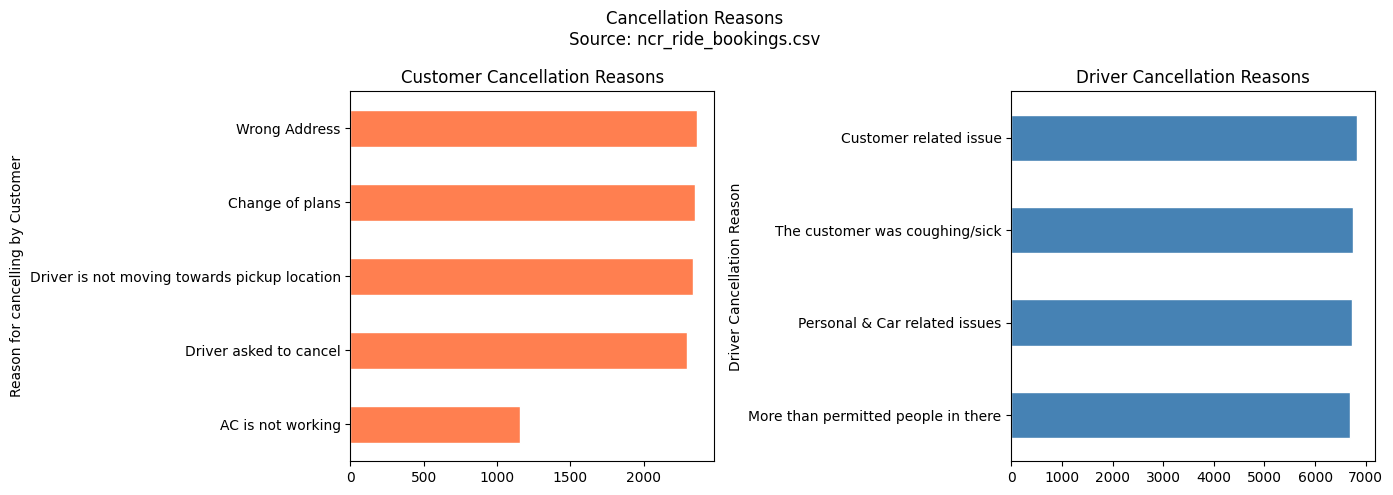

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cust_reasons.plot(kind='barh', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Customer Cancellation Reasons'); axes[0].invert_yaxis()
drv_reasons.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Driver Cancellation Reasons'); axes[1].invert_yaxis()
fig.suptitle('Cancellation Reasons\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/04_cancellation_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Cancellation rate by vehicle type
canc_by_veh = (df.groupby('Vehicle Type', observed=True)
               .apply(lambda g: g['is_cancelled'].sum() / len(g) * 100)
               .rename('canc_rate_pct').sort_values(ascending=False))
print('Cancellation rate by Vehicle Type (%):', canc_by_veh.round(1).to_string(), sep='\n')

# Cancellation rate by time slot
canc_by_slot = (df.groupby('time_slot', observed=True)
                .apply(lambda g: g['is_cancelled'].sum() / len(g) * 100)
                .rename('canc_rate_pct')
                .reindex([s for s in slot_order if s in df['time_slot'].cat.categories]))
print(); print('Cancellation rate by Time Slot (%):', canc_by_slot.round(1).to_string(), sep='\n')

# Cancellation rate by day of week
canc_by_dow = (df.groupby('day_name')
               .apply(lambda g: g['is_cancelled'].sum() / len(g) * 100)
               .rename('canc_rate_pct')
               .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']))
print(); print('Cancellation rate by Day of Week (%):', canc_by_dow.round(1).to_string(), sep='\n')

Cancellation rate by Vehicle Type (%):
Vehicle Type
Go Sedan         25.3
Bike             25.1
Premier Sedan    24.9
Go Mini          24.9
Auto             24.9
eBike            24.9
Uber XL          24.5

Cancellation rate by Time Slot (%):
time_slot
Early Morning    25.2
Morning          24.9
Afternoon        25.0
Evening          25.2
Night            24.6
Late Night       25.4

Cancellation rate by Day of Week (%):
day_name
Monday       25.7
Tuesday      25.2
Wednesday    24.8
Thursday     24.7
Friday       25.0
Saturday     24.7
Sunday       25.0


Customer cancellation rate by VTAT quartile:
vtat_q
Q1 (Low)      0.74
Q2            5.92
Q3            5.99
Q4 (High)    17.73


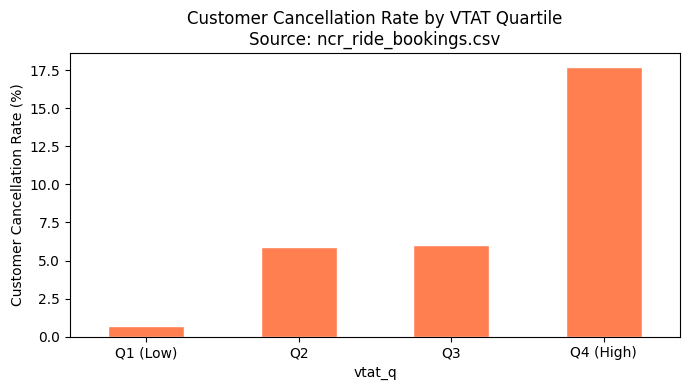

In [7]:
# VTAT quartile → customer cancellation rate
dispatched = df[df['Avg VTAT'].notna()].copy()
dispatched['vtat_q'] = pd.qcut(dispatched['Avg VTAT'], q=4,
                                labels=['Q1 (Low)','Q2','Q3','Q4 (High)'])
vtat_canc = (dispatched.groupby('vtat_q', observed=True)
             .apply(lambda g: (g['Booking Status'] == 'Cancelled by Customer').sum() / len(g) * 100)
             .rename('cust_canc_pct'))
print('Customer cancellation rate by VTAT quartile:', vtat_canc.round(2).to_string(), sep='\n')

fig, ax = plt.subplots(figsize=(7, 4))
vtat_canc.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Customer Cancellation Rate by VTAT Quartile\nSource: ncr_ride_bookings.csv')
ax.set_ylabel('Customer Cancellation Rate (%)'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
fig.savefig('outputs/plots/04_vtat_canc_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.2 No Driver Found Deep-Dive

In [8]:
ndf_by_veh = (df.groupby('Vehicle Type', observed=True)
              .apply(lambda g: (g['Booking Status'] == 'No Driver Found').sum() / len(g) * 100)
              .rename('ndf_rate_pct').sort_values(ascending=False))
print('No Driver Found rate by Vehicle Type (%):', ndf_by_veh.round(1).to_string(), sep='\n')

ndf_by_slot = (df.groupby('time_slot', observed=True)
               .apply(lambda g: (g['Booking Status'] == 'No Driver Found').sum() / len(g) * 100)
               .rename('ndf_rate_pct')
               .reindex([s for s in slot_order if s in df['time_slot'].cat.categories]))
print(); print('No Driver Found rate by Time Slot (%):', ndf_by_slot.round(1).to_string(), sep='\n')

ndf_monthly = (df.groupby('month')
               .apply(lambda g: (g['Booking Status'] == 'No Driver Found').sum() / len(g) * 100)
               .rename('ndf_rate_pct'))
print(); print('No Driver Found rate by Month (%):', ndf_monthly.round(1).to_string(), sep='\n')

ndf_by_zone = (df.groupby('pickup_zone')
               .apply(lambda g: (g['Booking Status'] == 'No Driver Found').sum() / len(g) * 100)
               .rename('ndf_rate_pct').sort_values(ascending=False))
print(); print('No Driver Found rate by Pickup Zone (%):', ndf_by_zone.round(1).to_string(), sep='\n')

No Driver Found rate by Vehicle Type (%):
Vehicle Type
Go Sedan         7.2
Auto             7.2
Uber XL          7.1
Premier Sedan    7.1
eBike            7.1
Go Mini          6.8
Bike             6.7

No Driver Found rate by Time Slot (%):
time_slot
Early Morning    7.2
Morning          7.0
Afternoon        7.1
Evening          7.0
Night            7.0
Late Night       6.4

No Driver Found rate by Month (%):
month
1     6.9
2     7.1
3     7.0
4     6.9
5     6.8
6     6.9
7     7.0
8     7.4
9     7.4
10    6.9
11    6.9
12    6.8

No Driver Found rate by Pickup Zone (%):
pickup_zone
Faridabad             7.9
Outer NCR             7.3
Gurgaon               7.1
Delhi Core            7.1
Delhi North           7.1
Noida                 7.0
Delhi East            6.9
Gurgaon Peripheral    6.9
Delhi South           6.9
Delhi West            6.8


## 4.3 Incomplete Rides

In [9]:
inc = df[df['Booking Status'] == 'Incomplete']
print('Incomplete Ride Reasons:', inc['Incomplete Rides Reason'].value_counts().to_string(), sep='\n')

inc_by_veh = (df.groupby('Vehicle Type', observed=True)
              .apply(lambda g: (g['Booking Status'] == 'Incomplete').sum() / len(g) * 100)
              .rename('inc_rate_pct').sort_values(ascending=False))
print(); print('Incomplete rate by Vehicle Type (%):', inc_by_veh.round(1).to_string(), sep='\n')

inc_by_slot = (df.groupby('time_slot', observed=True)
               .apply(lambda g: (g['Booking Status'] == 'Incomplete').sum() / len(g) * 100)
               .rename('inc_rate_pct')
               .reindex([s for s in slot_order if s in df['time_slot'].cat.categories]))
print(); print('Incomplete rate by Time Slot (%):', inc_by_slot.round(1).to_string(), sep='\n')

Incomplete Ride Reasons:
Incomplete Rides Reason
Customer Demand      3040
Vehicle Breakdown    3012
Other Issue          2948

Incomplete rate by Vehicle Type (%):
Vehicle Type
Go Mini          6.1
Go Sedan         6.0
Auto             6.0
eBike            6.0
Bike             5.9
Uber XL          5.9
Premier Sedan    5.9

Incomplete rate by Time Slot (%):
time_slot
Early Morning    5.5
Morning          6.0
Afternoon        6.0
Evening          6.1
Night            6.0
Late Night       5.8


## 4.4 VTAT / CTAT Drivers

Avg VTAT by Vehicle (min):
Vehicle Type
Uber XL          8.58
Bike             8.50
eBike            8.48
Go Mini          8.47
Auto             8.45
Premier Sedan    8.44
Go Sedan         8.40

Avg CTAT by Vehicle (min):
Vehicle Type
Premier Sedan    29.22
Uber XL          29.21
Bike             29.20
eBike            29.18
Go Mini          29.16
Auto             29.14
Go Sedan         29.04

Avg VTAT by Time Slot (min):
time_slot
Early Morning    8.45
Morning          8.48
Afternoon        8.47
Evening          8.45
Night            8.43
Late Night       8.46


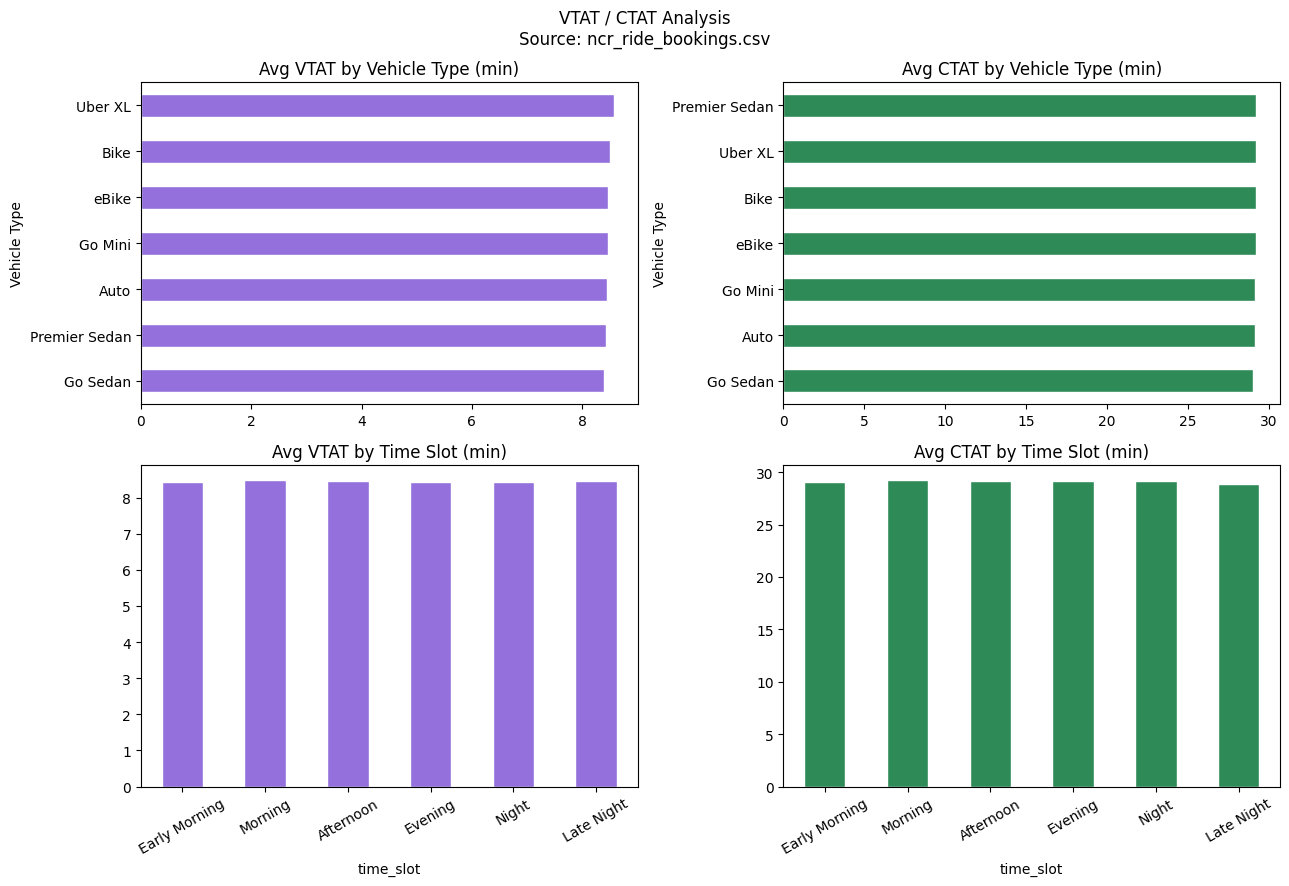

In [10]:
vtat_veh = df.groupby('Vehicle Type', observed=True)['Avg VTAT'].mean().sort_values(ascending=False)
ctat_veh = df.groupby('Vehicle Type', observed=True)['Avg CTAT'].mean().sort_values(ascending=False)
vtat_slot = (df.groupby('time_slot', observed=True)['Avg VTAT'].mean()
               .reindex([s for s in slot_order if s in df['time_slot'].cat.categories]))
ctat_slot = (df.groupby('time_slot', observed=True)['Avg CTAT'].mean()
               .reindex([s for s in slot_order if s in df['time_slot'].cat.categories]))

print('Avg VTAT by Vehicle (min):'); print(vtat_veh.round(2).to_string())
print(); print('Avg CTAT by Vehicle (min):'); print(ctat_veh.round(2).to_string())
print(); print('Avg VTAT by Time Slot (min):'); print(vtat_slot.round(2).to_string())

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
vtat_veh.plot(kind='barh', ax=axes[0,0], color='mediumpurple', edgecolor='white')
axes[0,0].set_title('Avg VTAT by Vehicle Type (min)'); axes[0,0].invert_yaxis()
ctat_veh.plot(kind='barh', ax=axes[0,1], color='seagreen', edgecolor='white')
axes[0,1].set_title('Avg CTAT by Vehicle Type (min)'); axes[0,1].invert_yaxis()
vtat_slot.plot(kind='bar', ax=axes[1,0], color='mediumpurple', edgecolor='white')
axes[1,0].set_title('Avg VTAT by Time Slot (min)'); axes[1,0].tick_params(axis='x', rotation=30)
ctat_slot.plot(kind='bar', ax=axes[1,1], color='seagreen', edgecolor='white')
axes[1,1].set_title('Avg CTAT by Time Slot (min)'); axes[1,1].tick_params(axis='x', rotation=30)
fig.suptitle('VTAT / CTAT Analysis\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/04_vtat_ctat.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 Rating Drivers

In [11]:
low_dr = completed[completed['Driver Ratings'] < 4.0]
print(f'Low-rated rides (Driver Rating < 4.0): {len(low_dr):,}  '
      f'({len(low_dr)/len(completed)*100:.1f}% of completed)')
print('By Vehicle Type:', low_dr.groupby('Vehicle Type', observed=True).size()
      .sort_values(ascending=False).to_string(), sep='\n')

corr_bv_dr  = completed[['Booking Value','Driver Ratings']].corr().iloc[0,1]
vtat_cr_sub = df[df['Avg VTAT'].notna() & df['Customer Rating'].notna()]
corr_vtat_cr = vtat_cr_sub[['Avg VTAT','Customer Rating']].corr().iloc[0,1]
corr_dist_cr = completed[['Ride Distance','Customer Rating']].corr().iloc[0,1]
print(f'\nCorr(Booking Value, Driver Rating)  : {corr_bv_dr:.4f}')
print(f'Corr(Avg VTAT, Customer Rating)     : {corr_vtat_cr:.4f}')
print(f'Corr(Ride Distance, Customer Rating): {corr_dist_cr:.4f}')

Low-rated rides (Driver Rating < 4.0): 21,021  (22.6% of completed)
By Vehicle Type:
Vehicle Type
Auto             5188
Go Mini          4261
Go Sedan         3762
Bike             3195
Premier Sedan    2504
eBike            1500
Uber XL           611

Corr(Booking Value, Driver Rating)  : -0.0002
Corr(Avg VTAT, Customer Rating)     : -0.0039
Corr(Ride Distance, Customer Rating): 0.0045


## 4.6 Revenue Diagnostics

In [12]:
fare_per_km_veh = completed.groupby('Vehicle Type', observed=True)['fare_per_km'].mean().sort_values(ascending=False)
print('Avg Fare/km by Vehicle Type (₹/km):', fare_per_km_veh.round(2).to_string(), sep='\n')

monthly_avg_fare = completed.groupby('month')['Booking Value'].mean().round(0)
print(); print('Monthly Avg Fare (₹):', monthly_avg_fare.to_string(), sep='\n')

route_gbv = completed.groupby('route')['Booking Value'].sum().sort_values(ascending=False)
top10p = route_gbv.head(max(1, len(route_gbv) // 10))
total_gbv = completed['Booking Value'].sum()
print(f'\nTop 10% of routes account for {top10p.sum()/total_gbv*100:.1f}% of total GBV')
print('Top 10 routes by GBV:'); print(route_gbv.head(10).apply(lambda x: f'₹{x:,.0f}').to_string())

# Save diagnostic table
diag = pd.DataFrame({
    'canc_rate_pct': canc_by_veh,
    'ndf_rate_pct': ndf_by_veh,
    'inc_rate_pct': inc_by_veh,
    'avg_vtat_min': vtat_veh,
    'avg_ctat_min': ctat_veh,
    'avg_fare_per_km': fare_per_km_veh,
})
diag.to_csv('outputs/reports/vehicle_diagnostics.csv')
print('\nSaved: outputs/reports/vehicle_diagnostics.csv')

Avg Fare/km by Vehicle Type (₹/km):
Vehicle Type
Go Sedan         34.66
Auto             34.00
Bike             33.89
Uber XL          33.85
Premier Sedan    33.73
Go Mini          33.49
eBike            32.47

Monthly Avg Fare (₹):
month
1     503.0
2     510.0
3     525.0
4     509.0
5     498.0
6     511.0
7     500.0
8     497.0
9     507.0
10    507.0
11    514.0
12    518.0

Top 10% of routes account for 24.5% of total GBV
Top 10 routes by GBV:
route
Nirman Vihar → Vatika Chowk            ₹9,284
Ashok Vihar → Basai Dhankot            ₹9,280
Anand Vihar ISBT → Noida Film City     ₹8,960
Ambience Mall → Akshardham             ₹8,518
Cyber Hub → Gurgaon Railway Station    ₹8,396
Greater Noida → Jor Bagh               ₹8,252
Noida Extension → Vaishali             ₹8,202
Greater Noida → Rithala                ₹8,082
Udyog Vihar → Tagore Garden            ₹7,940
Cyber Hub → Chanakyapuri               ₹7,900

Saved: outputs/reports/vehicle_diagnostics.csv


## Limitations
- No driver ID — cannot attribute cancellations, low ratings, or VTAT issues to individual drivers.
- Driver payout, commission, operating cost are unavailable — net profitability per vehicle/route cannot be calculated.
- CAC, LTV, ROAS are unavailable (no cost or acquisition channel data).